# **Heart disease prediction using ML**


# **Importing the Functions**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

# **Importing the dataset**

In [ ]:
df = pd.read_csv('heart.csv')
df.head()


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
#checking the size of the dataset
df.shape

(303, 14)

# **Visualizing the Dataset**

In [ ]:
#checking for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [ ]:
#looking for duplicate values
df.duplicated().sum()

1

In [ ]:
#display duplicated data
df[df.duplicated()]

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [ ]:
#dropping duplicated data and checking size of dataset again
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.shape

(302, 14)

# **Correlation**

<Axes: >

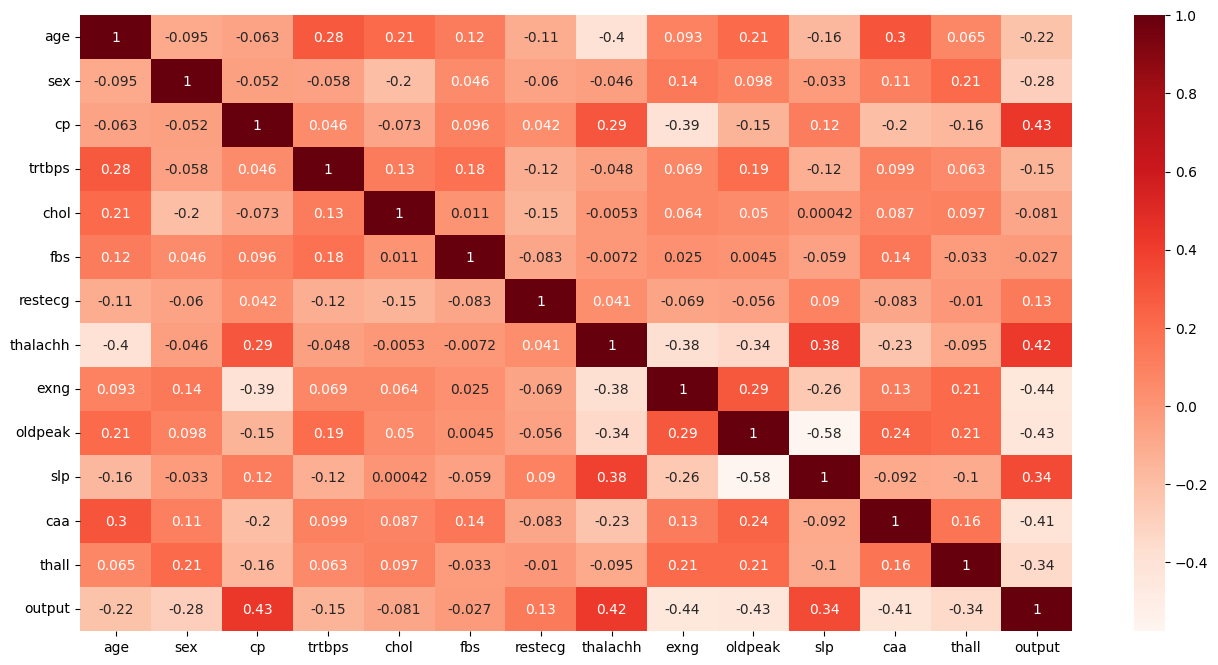

In [ ]:
plt.figure(figsize=(16,8))
sns.heatmap(df.corr(),annot=True,cmap='Reds')

In [ ]:
correlation_matrix = df.corr()
correlation_matrix["output"]


age        -0.221476
sex        -0.283609
cp          0.432080
trtbps     -0.146269
chol       -0.081437
fbs        -0.026826
restecg     0.134874
thalachh    0.419955
exng       -0.435601
oldpeak    -0.429146
slp         0.343940
caa        -0.408992
thall      -0.343101
output      1.000000
Name: output, dtype: float64

# **Plot Visualization of Dataset**

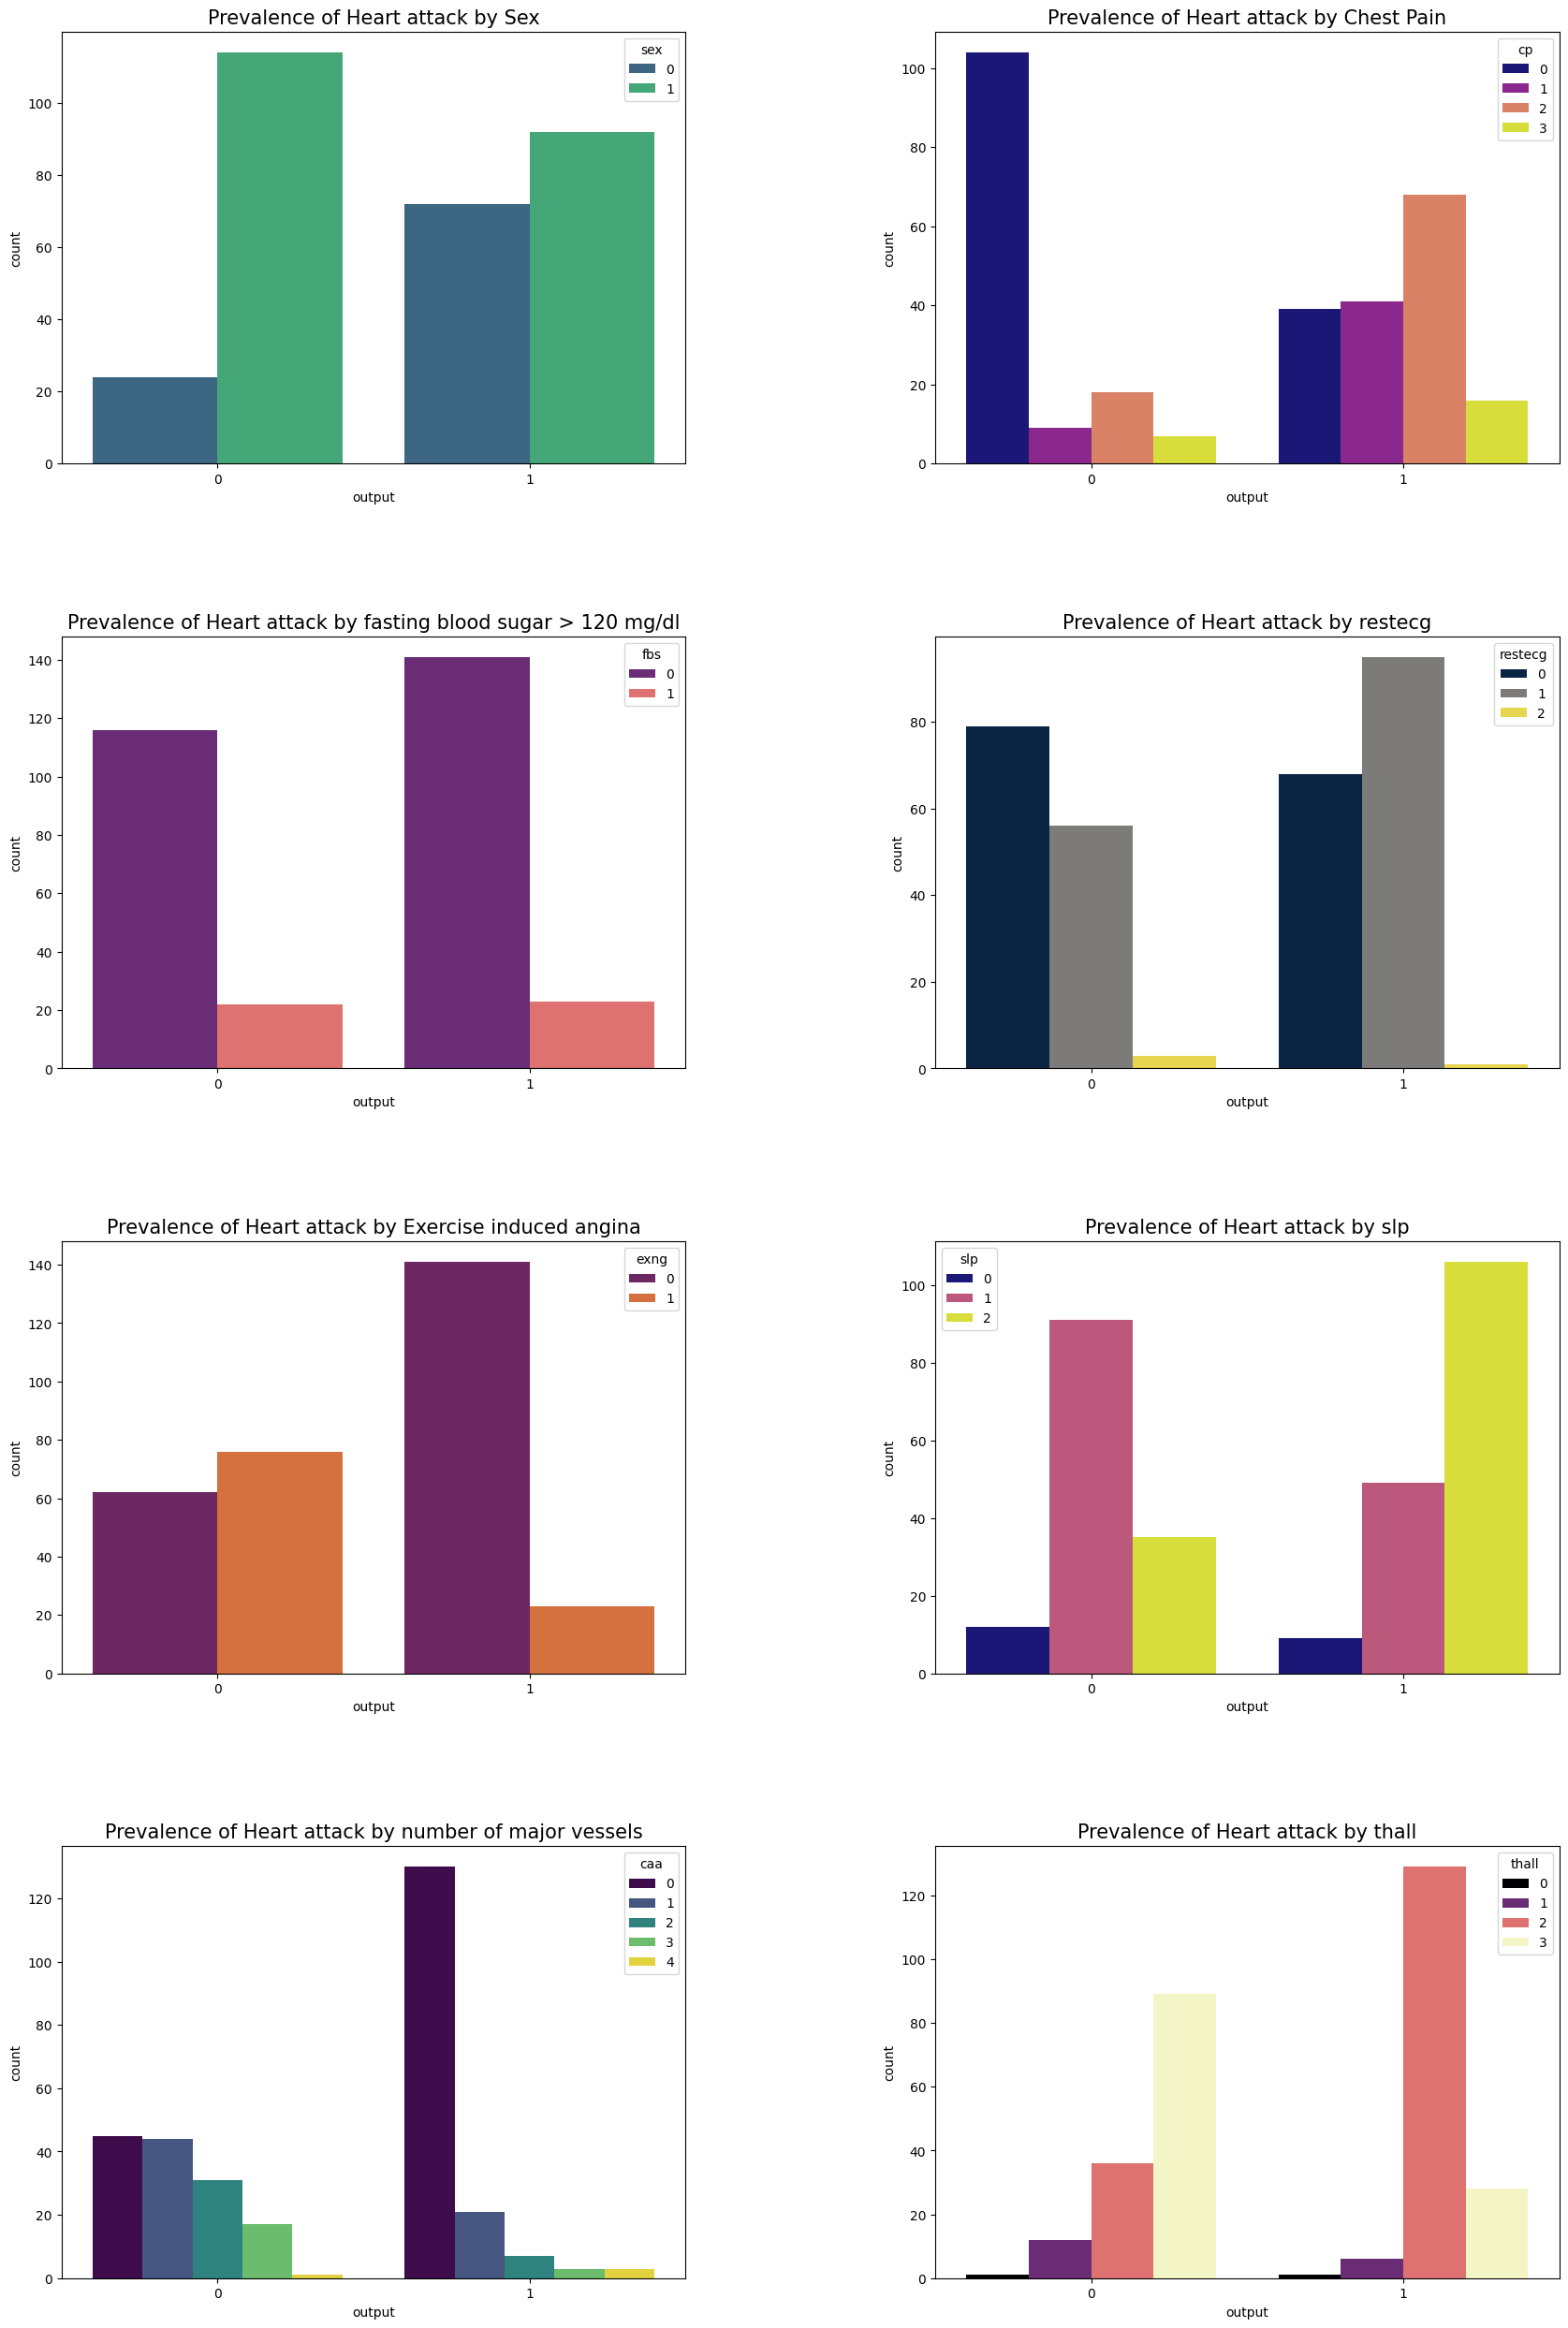

In [ ]:
plt.figure(figsize=(20, 30))
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.4, hspace=0.4)

plt.subplot(4, 2, 1)
plt.title('Prevalence of Heart attack by Sex', fontsize=15)
sns.countplot(x='output', hue='sex', data=df, palette='viridis')  # Change the color palette

plt.subplot(4, 2, 2)
plt.title('Prevalence of Heart attack by Chest Pain', fontsize=15)
sns.countplot(x='output', hue='cp', data=df, palette='plasma')  # Change the color palette

plt.subplot(4, 2, 3)
plt.title('Prevalence of Heart attack by fasting blood sugar > 120 mg/dl', fontsize=15)
sns.countplot(x='output', hue='fbs', data=df, palette='magma')  # Change the color palette

plt.subplot(4, 2, 4)
plt.title('Prevalence of Heart attack by restecg', fontsize=15)
sns.countplot(x='output', hue='restecg', data=df, palette='cividis')  # Change the color palette

plt.subplot(4, 2, 5)
plt.title('Prevalence of Heart attack by Exercise induced angina', fontsize=15)
sns.countplot(x='output', hue='exng', data=df, palette='inferno')  # Change the color palette

plt.subplot(4, 2, 6)
plt.title('Prevalence of Heart attack by slp', fontsize=15)
sns.countplot(x='output', hue='slp', data=df, palette='plasma')  # Change the color palette

plt.subplot(4, 2, 7)
plt.title('Prevalence of Heart attack by number of major vessels', fontsize=15)
sns.countplot(x='output', hue='caa', data=df, palette='viridis')  # Change the color palette

plt.subplot(4, 2, 8)
plt.title('Prevalence of Heart attack by thall', fontsize=15)
sns.countplot(x='output', hue='thall', data=df, palette='magma')  # Change the color palette

plt.show()


<Axes: title={'center': 'Prevalence of Heart attack by old peak'}, xlabel='oldpeak', ylabel='Count'>

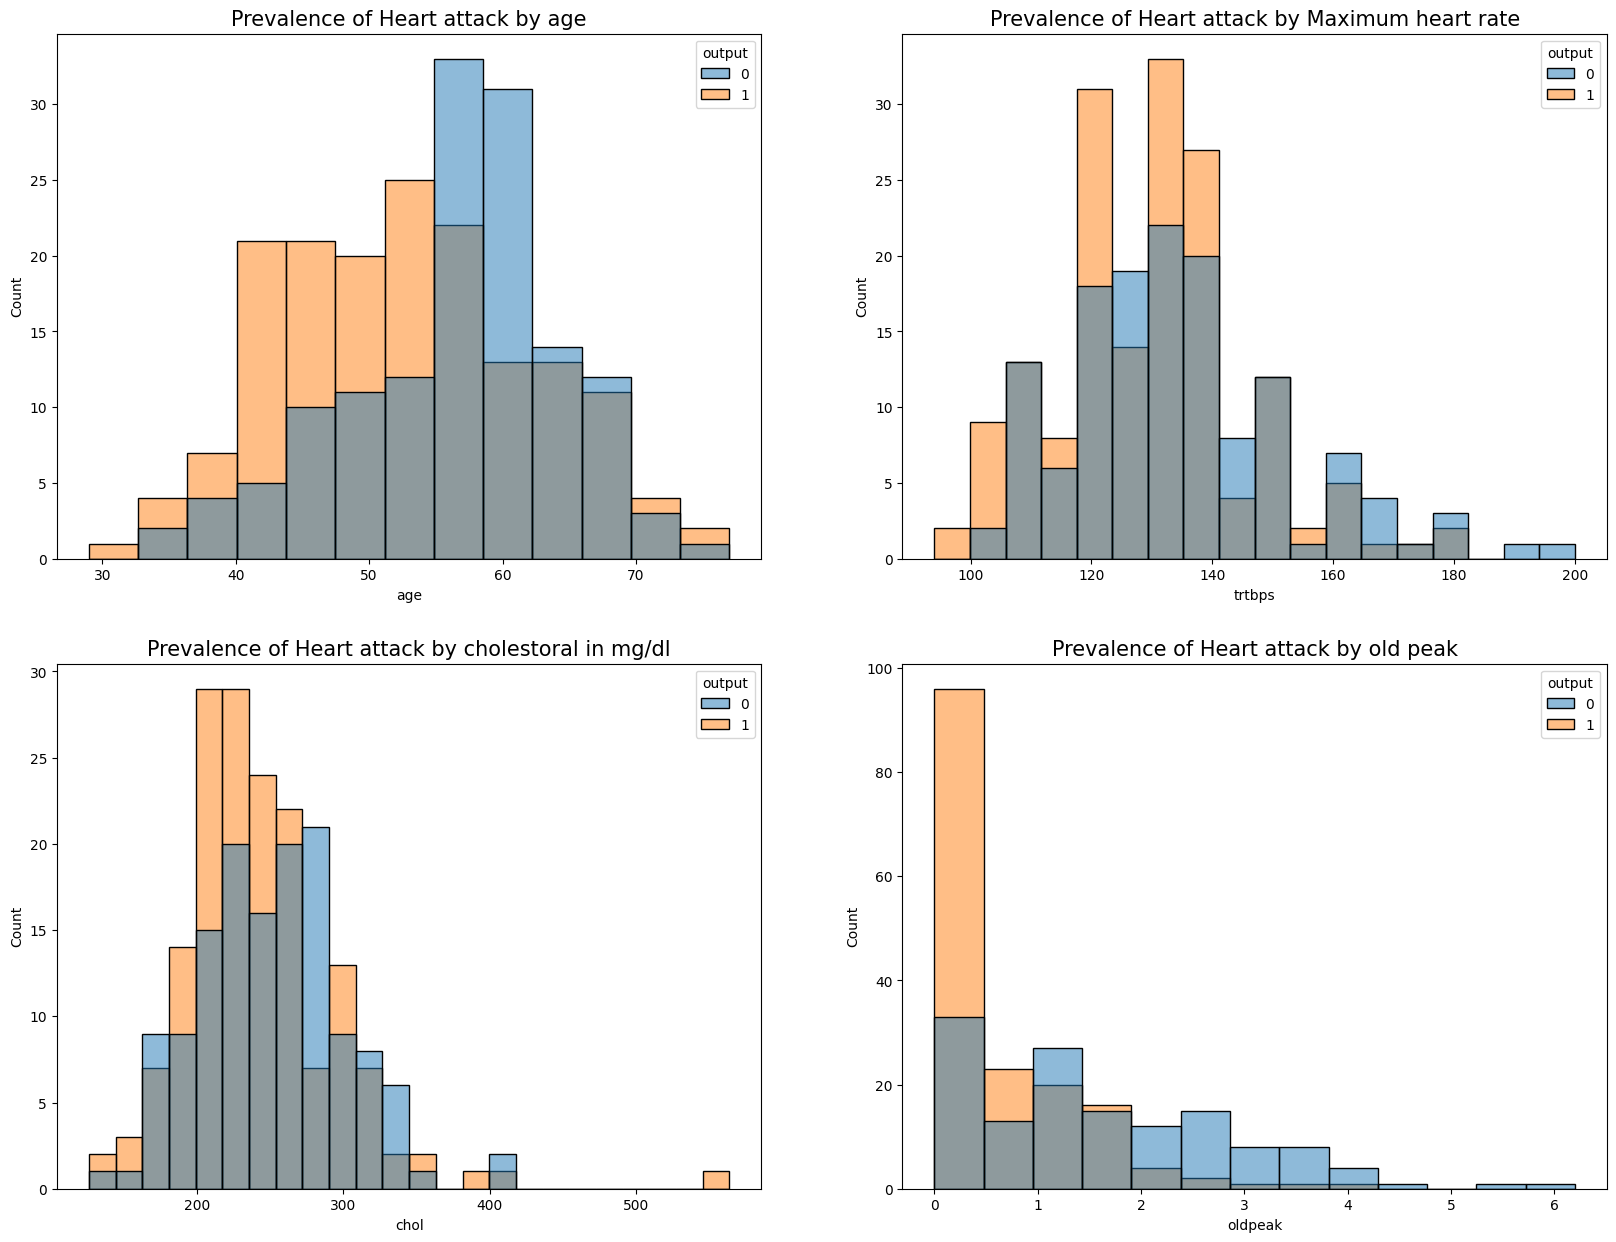

In [ ]:
plt.figure(figsize=(20,15))
plt.subplot(2,2,1)
plt.title('Prevalence of Heart attack by age',fontsize=15)
sns.histplot(x = df['age'], hue = df['output'])

plt.subplot(2,2,2)
plt.title('Prevalence of Heart attack by Maximum heart rate',fontsize=15)
sns.histplot(x = df['trtbps'], hue = df['output'])

plt.subplot(2,2,3)
plt.title('Prevalence of Heart attack by cholestoral in mg/dl',fontsize=15)
sns.histplot(x = df['chol'], hue = df['output'])

plt.subplot(2,2,4)
plt.title('Prevalence of Heart attack by old peak',fontsize=15)
sns.histplot(x = df['oldpeak'],hue = df['output'])

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:854: UserWarning: Ignoring `palette` because no `hue` variab

<Figure size 2000x2000 with 0 Axes>

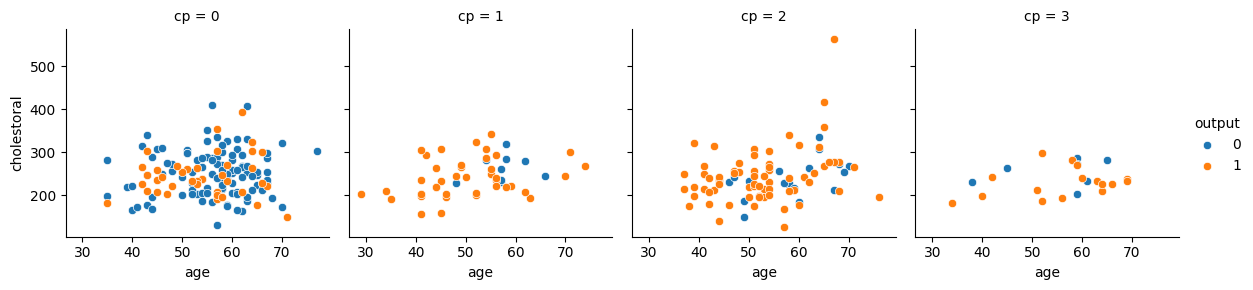

In [ ]:
plt.figure(figsize=(20, 20))
g = sns.FacetGrid(df, col="cp", hue="output")
g.map(sns.scatterplot, 'age', 'chol', palette='Set2')  # Change the color palette
g.set_axis_labels('age', 'cholestoral')
g.add_legend()

plt.show()


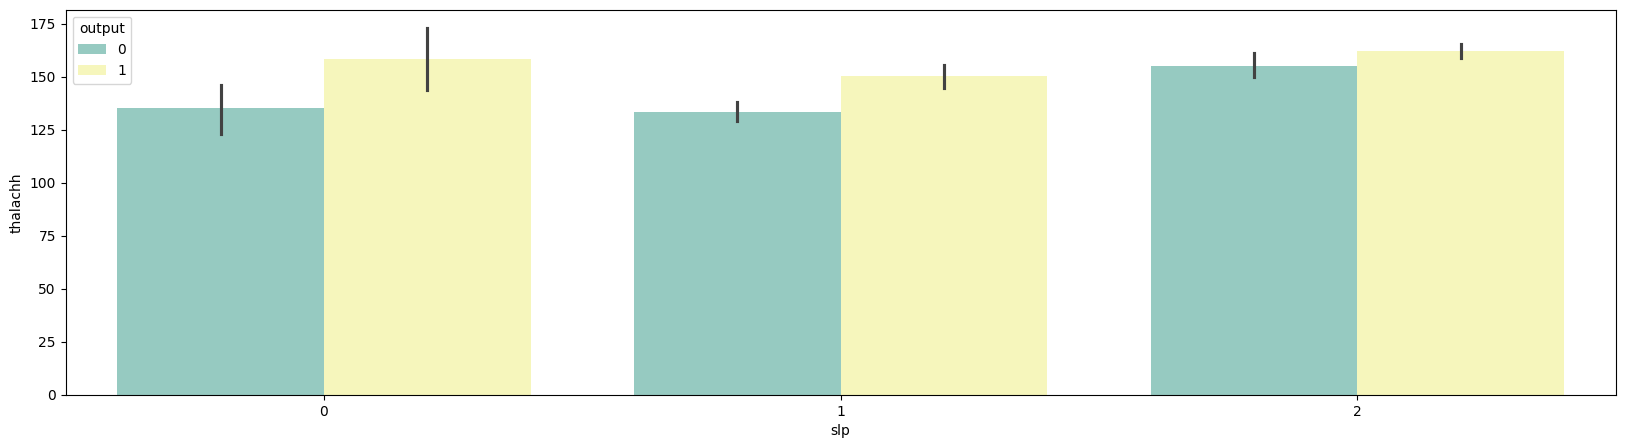

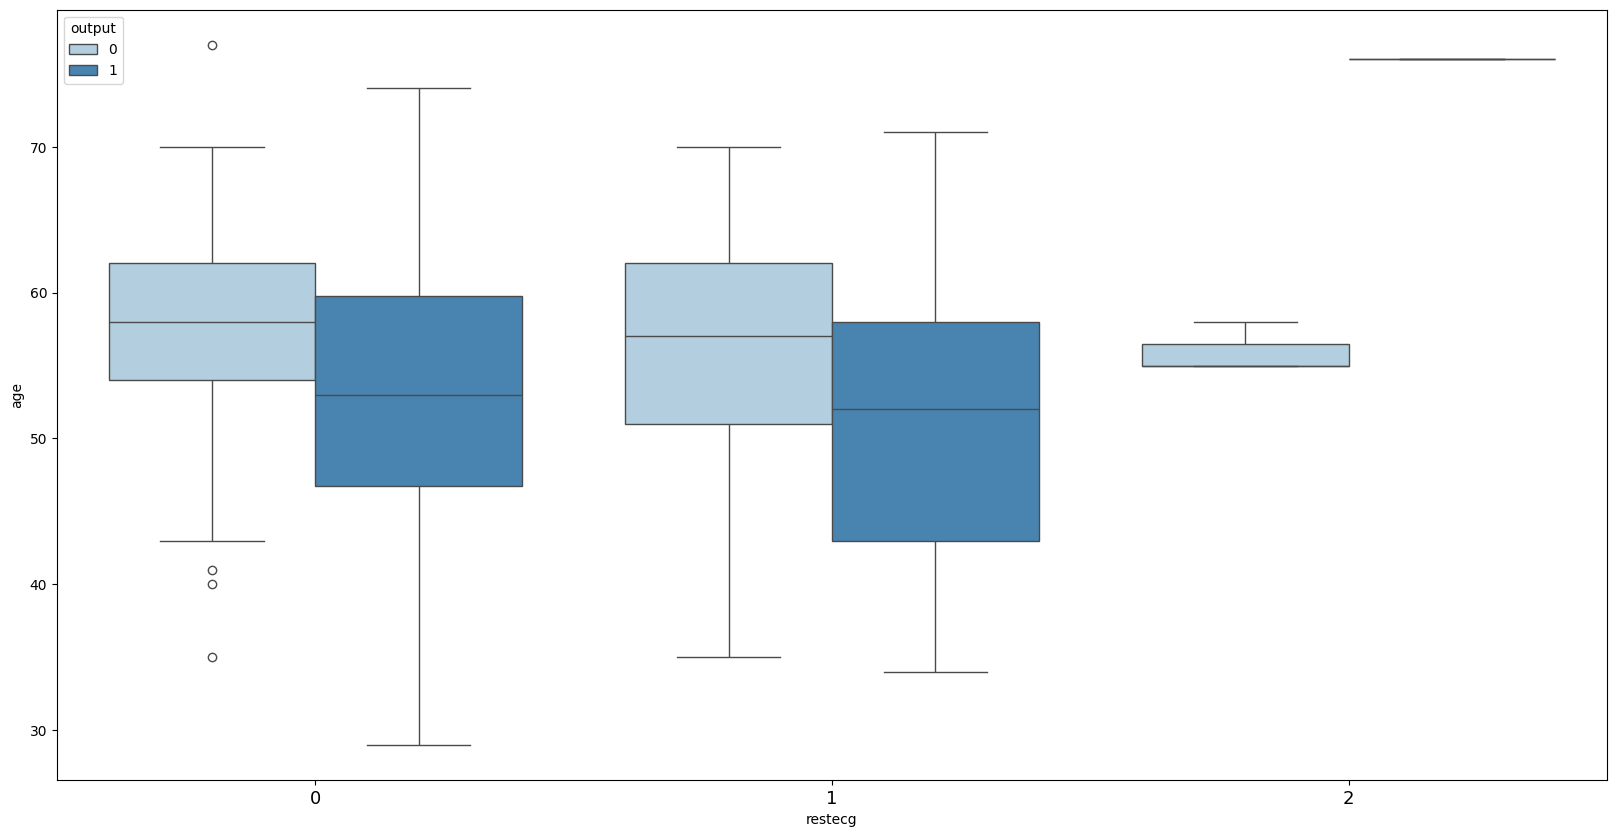

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Bar plot with a different color palette
plt.figure(figsize=(20, 5))
sns.barplot(x=df['slp'], y=df['thalachh'], hue=df['output'], palette='Set3')  # Different color palette
plt.show()

# Box plot with a different color palette
plt.figure(figsize=(20, 10))
plt.xticks(fontsize=13)
sns.boxplot(x=df['restecg'], y=df['age'], hue=df['output'], palette='Blues')  # Different color palette
plt.show()


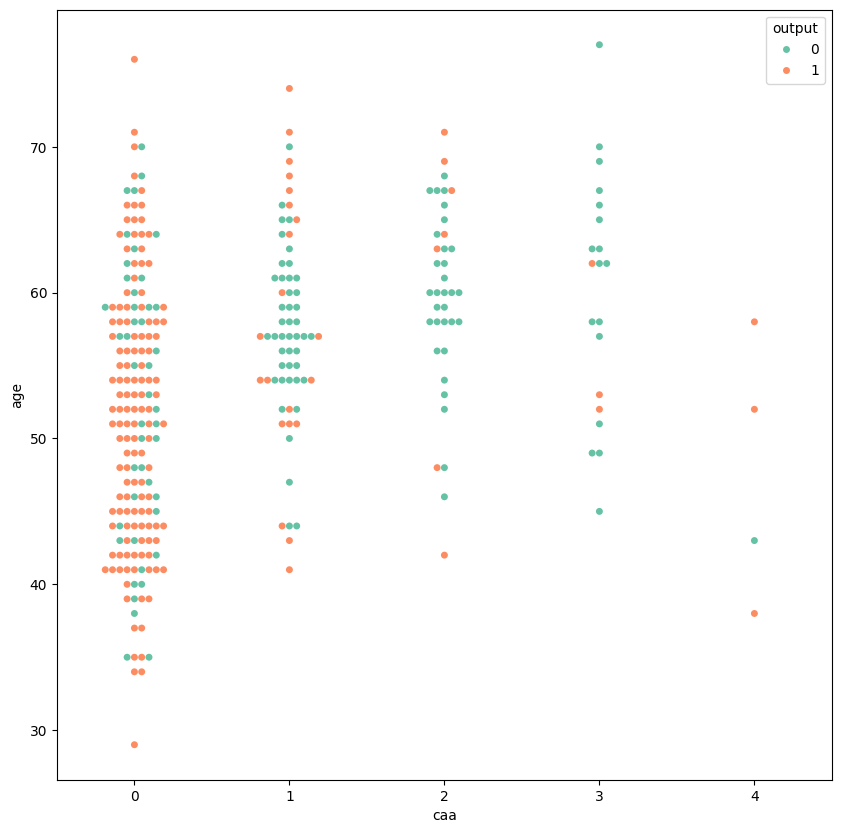

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
sns.swarmplot(x=df['caa'], y=df['age'], hue=df['output'], palette='Set2')  # Different color palette
plt.show()


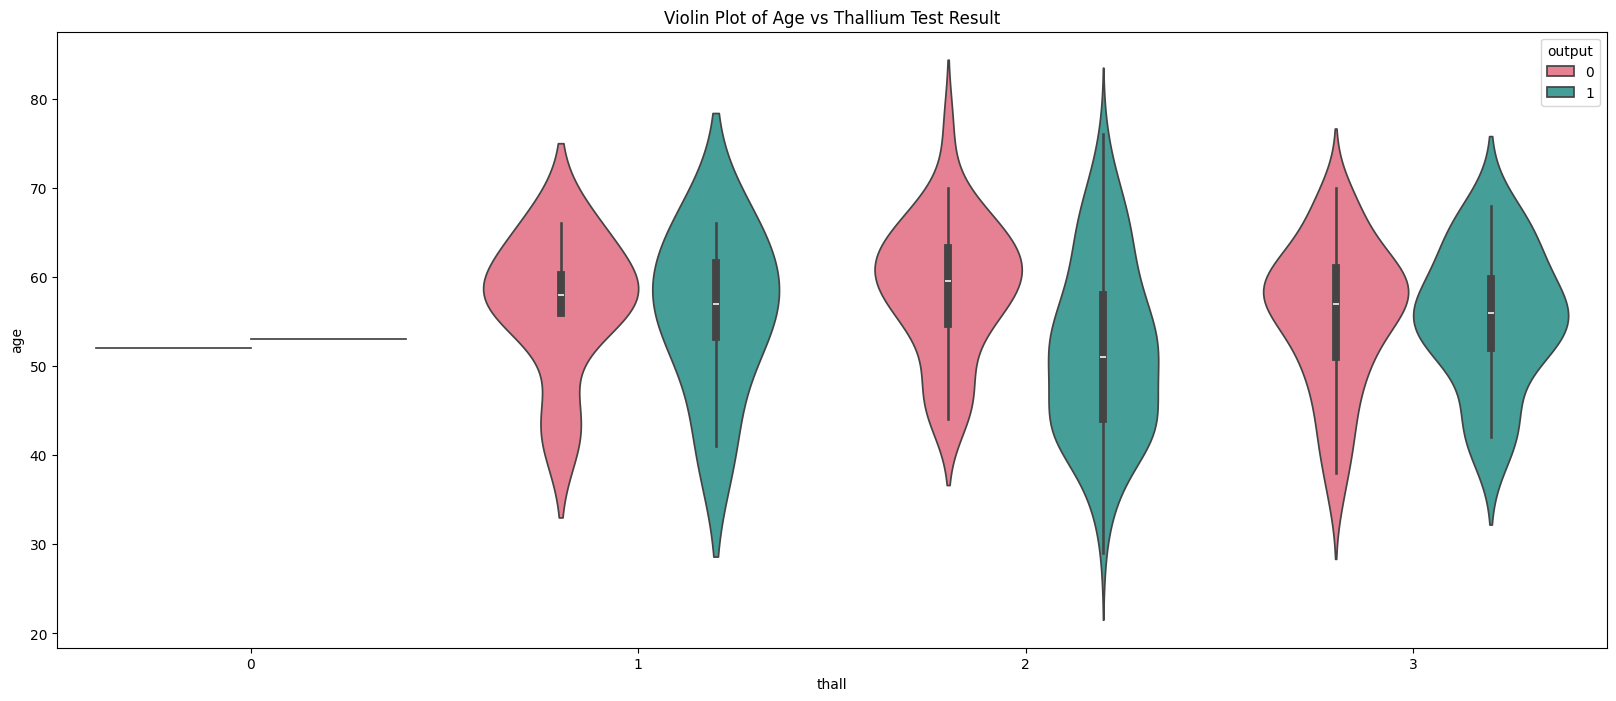

In [ ]:
plt.figure(figsize=(20, 8))
sns.violinplot(x=df['thall'], y=df['age'], hue=df['output'], palette='husl')  # Change the color palette
plt.title('Violin Plot of Age vs Thallium Test Result')
plt.show()


# **Checking for Outliners and Treating them**

In [ ]:
continuous_cols = ["age", "trtbps", "chol", "thalachh", "oldpeak"]
continuous_data = df[continuous_cols]

def detect_outliers(column):
    q1 = column.quantile(0.25)
    q3 = column.quantile(0.75)
    irq = q3 - q1
    outliers = column[(column <= q1 - 1.5 * irq) | (column >= q3 + 1.5 * irq)]
    percentage_outliers = len(outliers) / len(df) * 100.0
    return len(outliers), percentage_outliers

outliers_info = continuous_data.apply(detect_outliers)

for column, (num_outliers, perc_outliers) in outliers_info.items():
    print(f"Column {column} outliers = {num_outliers} => {perc_outliers:.2f}%")


Column age outliers = 0.0 => 0.00%
Column trtbps outliers = 13.0 => 4.30%
Column chol outliers = 5.0 => 1.66%
Column thalachh outliers = 1.0 => 0.33%
Column oldpeak outliers = 8.0 => 2.65%


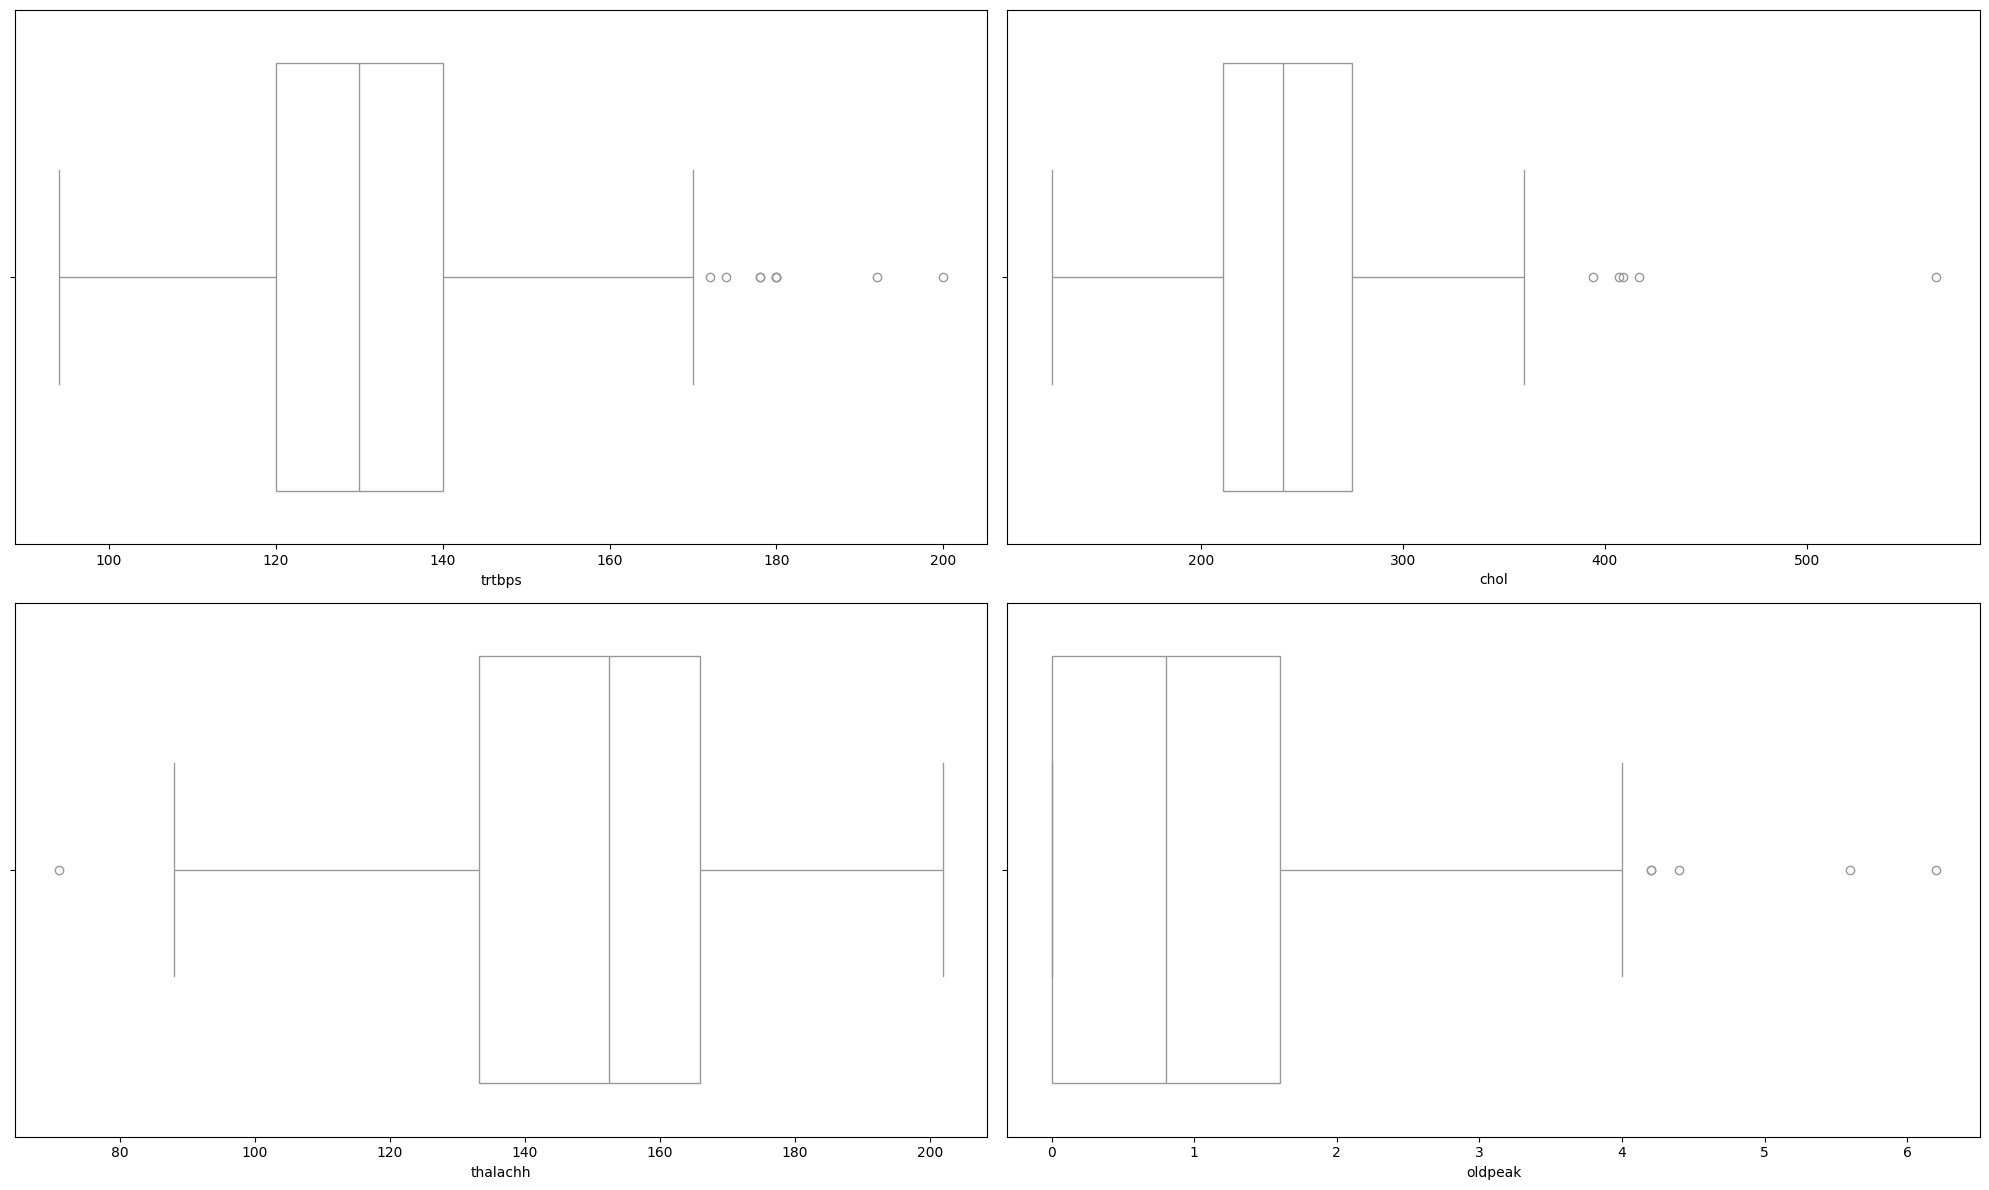

Outliers Present at position: 

trtbps: (array([  8, 101, 110, 152, 194, 202, 222, 227, 240, 247, 259, 265, 291]),)
chol: (array([ 28,  85,  96, 219, 245]),)
thalachh: (array([271]),)
oldpeak: (array([101, 203, 220, 249, 290]),)


In [ ]:
continuous_cols = ["age", "trtbps", "chol", "thalachh", "oldpeak"]
fig, ax1 = plt.subplots(2, 2, figsize=(20, 12))

# Display boxplots
for i in range(2):
    for j in range(2):
        column_name = continuous_cols[1:][i * 2 + j]
        sns.boxplot(data=df, x=column_name, saturation=1, ax=ax1[i][j], color="white")

plt.tight_layout()
plt.show()

# Display the position of outliers
print("Outliers Present at position: \n")
outlier_positions = {
    "trtbps": np.where(df['trtbps'] > 165),
    "chol": np.where(df['chol'] > 360),
    "thalachh": np.where(df['thalachh'] < 80),
    "oldpeak": np.where(df['oldpeak'] > 4),
}

for column, positions in outlier_positions.items():
    print(f"{column}: {positions}")

In [ ]:
log_transform_cols = ["age", "trtbps", "chol", "thalachh"]
df[log_transform_cols] = df[log_transform_cols].apply(np.log)

print("---Log Transform performed---")

# Outliers detection after log transformation
continuous_cols = ["age", "trtbps", "chol", "thalachh", "oldpeak"]

for column in continuous_cols:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    irq = q3 - q1
    outliers = df[column][(df[column] <= q1 - 1.5 * irq) | (df[column] >= q3 + 1.5 * irq)]
    percentage_outliers = len(outliers) / len(df) * 100.0
    print(f"Column {column} outliers = {len(outliers)} => {percentage_outliers:.2f}%")

---Log Transform performed---
Column age outliers = 1 => 0.33%
Column trtbps outliers = 9 => 2.98%
Column chol outliers = 6 => 1.99%
Column thalachh outliers = 4 => 1.32%
Column oldpeak outliers = 8 => 2.65%


# **Splitting the dataset into the Training set and Test set**

In [ ]:
from sklearn.model_selection import train_test_split
X=df.iloc[:, :-1].values
y=df.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.18, random_state = 9)

In [ ]:
print(X_train)

[[3.78418963 1.         1.         ... 2.         0.         2.        ]
 [3.97029191 1.         0.         ... 2.         0.         3.        ]
 [3.36729583 1.         1.         ... 2.         0.         2.        ]
 ...
 [4.12713439 0.         0.         ... 1.         3.         2.        ]
 [3.87120101 1.         0.         ... 2.         0.         2.        ]
 [3.8501476  1.         0.         ... 2.         0.         2.        ]]


In [ ]:
print(y_train)

[1 1 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 1 1 1 0 0 1 1 1 1 1 1 0
 1 1 1 1 1 1 0 0 1 1 1 0 1 0 1 1 0 0 0 1 1 0 1 0 0 0 1 1 0 1 0 0 1 1 1 1 1
 1 0 0 1 1 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 1 0 1 1 0 1 1 0 1 1 1 0 0 1 0
 1 0 1 0 1 0 1 1 0 0 0 0 0 1 1 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1 0 1 0 1 1 0
 1 1 1 1 0 0 1 0 1 1 1 0 1 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0 1
 1 1 1 0 1 0 0 1 0 0 1 1 0 0 0 1 1 0 1 1 1 0 0 1 1 0 1 0 0 1 0 0 0 1 1 1 0
 1 1 0 0 1 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 1 1 0 1 1]


In [ ]:
print(X_test)

[[4.17438727 0.         2.         5.07517382 5.88610403 0.
  0.         5.01727984 0.         0.8        2.         0.
  2.        ]
 [4.17438727 0.         2.         5.04342512 5.59471138 0.
  1.         4.99721227 0.         0.8        2.         0.
  2.        ]
 [3.91202301 1.         0.         5.01063529 5.49306144 0.
  0.         4.85203026 0.         2.6        1.         0.
  3.        ]
 [4.15888308 1.         3.         4.70048037 5.35185813 0.
  0.         4.9698133  1.         1.8        1.         0.
  2.        ]
 [3.87120101 1.         2.         4.82028157 5.54126355 1.
  1.         5.16478597 0.         0.         2.         2.
  2.        ]
 [4.20469262 1.         0.         4.78749174 5.433722   0.
  0.         4.8598124  1.         2.6        1.         2.
  3.        ]
 [3.66356165 1.         2.         4.94164242 5.77144112 0.
  0.         5.20400669 0.         0.         2.         0.
  2.        ]
 [4.04305127 0.         0.         4.78749174 5.86929691 0.
  

In [ ]:
print(y_test)

[1 1 0 1 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1 1 0 0 0 1 1 0 1 1 1 0 1 1 1 1 0
 0 1 1 1 1 0 0 0 0 1 1 0 0 0 0 1 0 0]


# **Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
print(X_train)

[[-1.10410822  0.68573909  0.03979928 ...  0.97482408 -0.71605086
  -0.45966489]
 [-0.0408536   0.68573909 -0.94324296 ...  0.97482408 -0.71605086
   1.13945099]
 [-3.48593968  0.68573909  0.03979928 ...  0.97482408 -0.71605086
  -0.45966489]
 ...
 [ 0.85523152 -1.45828059 -0.94324296 ... -0.65207827  2.29868601
  -0.45966489]
 [-0.60698777  0.68573909 -0.94324296 ...  0.97482408 -0.71605086
  -0.45966489]
 [-0.72727181  0.68573909 -0.94324296 ...  0.97482408 -0.71605086
  -0.45966489]]


In [ ]:
print(X_test)

[[ 1.12520053e+00 -1.45828059e+00  1.02284152e+00  1.48372414e+00
   1.91486691e+00 -4.19750493e-01 -9.90078821e-01  1.01075211e-01
  -7.17870060e-01 -2.01418980e-01  9.74824084e-01 -7.16050862e-01
  -4.59664889e-01]
 [ 1.12520053e+00 -1.45828059e+00  1.02284152e+00  1.24260211e+00
   4.94893678e-01 -4.19750493e-01  9.20463904e-01 -2.85883882e-02
  -7.17870060e-01 -2.01418980e-01  9.74824084e-01 -7.16050862e-01
  -4.59664889e-01]
 [-3.73760245e-01  6.85739087e-01 -9.43242959e-01  9.93573050e-01
  -4.52336650e-04 -4.19750493e-01 -9.90078821e-01 -9.66660533e-01
  -7.17870060e-01  1.31896945e+00 -6.52078273e-01 -7.16050862e-01
   1.13945099e+00]
 [ 1.03662075e+00  6.85739087e-01  2.00588376e+00 -1.36196243e+00
  -6.88544228e-01 -4.19750493e-01 -9.90078821e-01 -2.05622819e-01
   1.39300976e+00  6.43241257e-01 -6.52078273e-01 -7.16050862e-01
  -4.59664889e-01]
 [-6.06987771e-01  6.85739087e-01  1.02284152e+00 -4.52107548e-01
   2.34439292e-01  2.38236766e+00  9.20463904e-01  1.05416436e+00


# **Finding the Best Indices for the Logistic Regression Model**

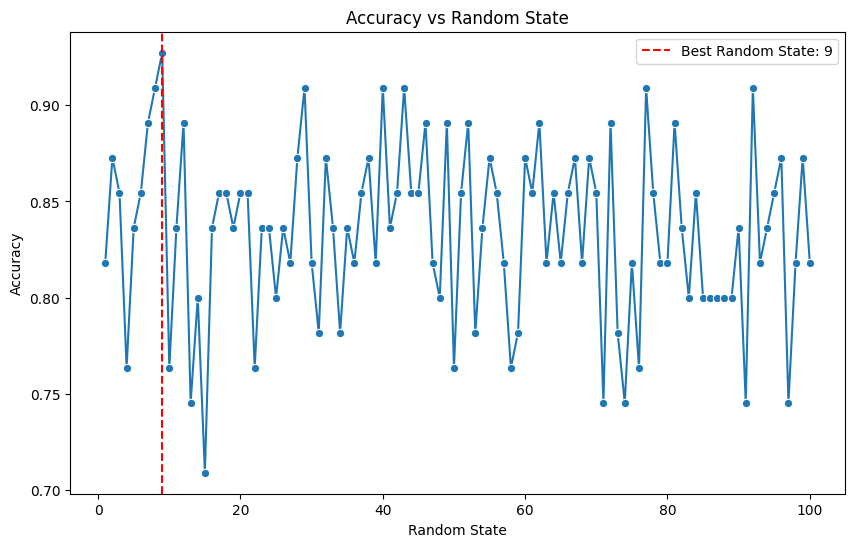

Best Random State: 9
Corresponding Accuracy: 0.9273


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def find_best_random_state(X, y, model, test_size=0.18, iterations=100):
    random_states = list(range(1, iterations + 1))
    accuracies = []

    for i in random_states:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=i)
        model.fit(X_train, y_train.ravel())  # Use 'ravel()' to flatten y_train
        predict_values = model.predict(X_test)
        accuracies.append(accuracy_score(y_test, predict_values))

    best_index = accuracies.index(max(accuracies))
    best_random_state = random_states[best_index]
    best_accuracy = accuracies[best_index]

    # Plotting
    plt.figure(figsize=(10, 6))
    sns.lineplot(x=random_states, y=accuracies, marker='o')
    plt.title('Accuracy vs Random State')
    plt.xlabel('Random State')
    plt.ylabel('Accuracy')
    plt.axvline(x=best_random_state, color='r', linestyle='--', label=f'Best Random State: {best_random_state}')
    plt.legend()
    plt.show()

    return best_random_state, best_accuracy

# Example usage
lr = LogisticRegression(solver='lbfgs', max_iter=10000)
best_random_state, best_accuracy = find_best_random_state(X, y, lr)

print(f"Best Random State: {best_random_state}")
print(f"Corresponding Accuracy: {best_accuracy:.4f}")

# **Training the Logistic Regression model on the Training set**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

#Set the desired random state with the highest accuracy
best_random_state = 9

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.18, random_state=best_random_state)

lr = LogisticRegression(solver='lbfgs', max_iter=10000)
model_lr = lr.fit(X_train, y_train.ravel())

predict_values_lr = model_lr.predict(X_test)



# **Making the Confusion Matrix and printing accuracy**

In [ ]:
conf_matrix = confusion_matrix(y_test, predict_values_lr)
print(conf_matrix)
accuracy_score(y_test, predict_values_lr)


[[22  1]
 [ 3 29]]


0.9272727272727272

# **Classification Report**

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, predict_values_lr))



Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        23
           1       0.97      0.91      0.94        32

    accuracy                           0.93        55
   macro avg       0.92      0.93      0.93        55
weighted avg       0.93      0.93      0.93        55



# **Visualizing the Results of the Model**

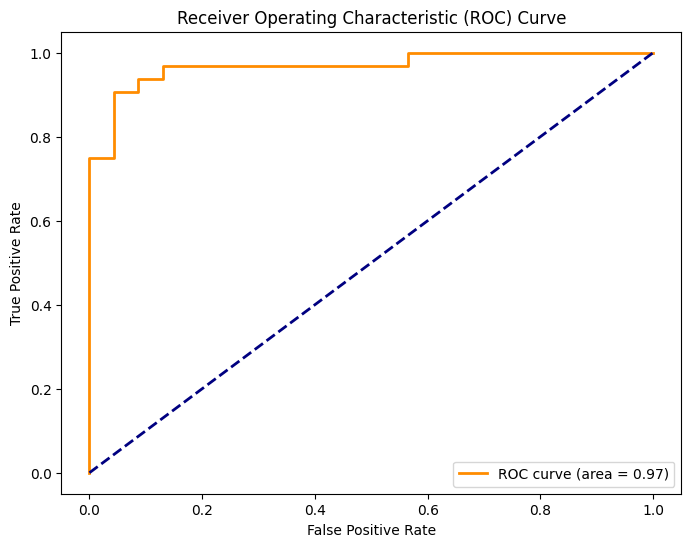

AUC Score: 0.96875


In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, roc_auc_score

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, model_lr.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()



# Calculate the predicted probabilities
predicted_probabilities = model_lr.predict_proba(X_test)[:, 1]

# Calculate AUC score
auc_score = roc_auc_score(y_test, predicted_probabilities)

# Print AUC score
print("AUC Score:", auc_score)

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report


# Split features and target
X = data.drop('target', axis=1)
y = data['target']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 2: Define base models
base_models = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svm', SVC(kernel='linear', probability=True, random_state=42))
]

# Step 3: Define the meta-model (Logistic Regression in this case)
meta_model = LogisticRegression(max_iter=1000, random_state=42)

# Step 4: Create the stacking classifier
stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5)

# Step 5: Train the model
stacking_model.fit(X_train, y_train)

# Step 6: Evaluate the model
y_pred = stacking_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Stacking Model Accuracy: {accuracy:.2f}")



0.9872727272727272


# **Training the Random Forest model on the Training set**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.18, random_state=9)

# Create a Random Forest Regressor
rf = RandomForestRegressor()

# Define the parameter distribution to sample from
param_dist = {
    'n_estimators': np.arange(50, 200, 10),
    'max_depth': [None] + list(np.arange(10, 110, 10)),
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Use RandomizedSearchCV to find the best parameters
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=50, cv=5, scoring='neg_mean_squared_error', random_state=9)
random_search.fit(X_train, y_train)

# Get the best parameters
best_params = random_search.best_params_
print(f'Best Parameters: {best_params}')

# Use the best parameters to train the model
best_rf = RandomForestRegressor(**best_params)
best_rf.fit(X_train, y_train)

# Make predictions on the test set
predict_values_best_rf = best_rf.predict(X_test)

# Evaluate the performance using Mean Squared Error
mse_best = mean_squared_error(y_test, predict_values_best_rf)
print(f'Mean Squared Error with Best Parameters: {mse_best}')


Best Parameters: {'n_estimators': 170, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_depth': 70}
Mean Squared Error with Best Parameters: 0.0919343682394403


# **Making the Confusion Matrix and printing accuracy**

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Convert the regression predictions to binary by rounding to the nearest integer
binary_predictions_rf = np.round(predict_values_best_rf)

# Create a confusion matrix
conf_matrix_rf = confusion_matrix(y_test, binary_predictions_rf)

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix_rf)

# Print the accuracy
accuracy_rf = accuracy_score(y_test, binary_predictions_rf)
print(f'Accuracy: {accuracy_rf}')


Confusion Matrix:
[[20  3]
 [ 2 30]]
Accuracy: 0.9090909090909091


# **Classification Report**


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, binary_predictions_rf))


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        23
           1       0.91      0.94      0.92        32

    accuracy                           0.91        55
   macro avg       0.91      0.90      0.91        55
weighted avg       0.91      0.91      0.91        55



# **Visualizing the Results of the Model**

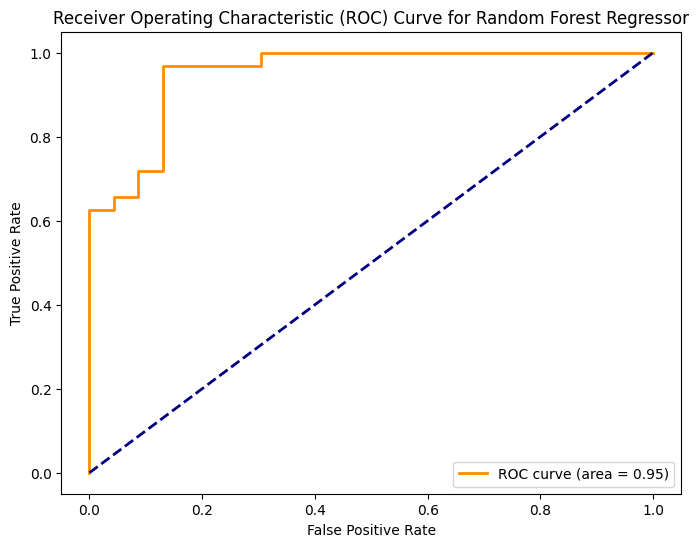

AUC Score for Random Forest Regressor: 0.9510869565217391


In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# ROC Curve for Random Forest Regressor
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict(X_test))
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc_rf))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest Regressor')
plt.legend(loc="lower right")
plt.show()

# Calculate the predicted probabilities for Random Forest Regressor
predicted_probabilities_rf = best_rf.predict(X_test)

# Calculate AUC score for Random Forest Regressor
auc_score_rf = roc_auc_score(y_test, predicted_probabilities_rf)

# Print AUC score for Random Forest Regressor
print("AUC Score for Random Forest Regressor:", auc_score_rf)


# **Training the XGBoost model on the Training set**




In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Assuming X and y are your features and target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.18, random_state=9)

# Create an XGBoost Regressor
xgb = XGBRegressor()

# Define the parameter distribution to sample from
param_dist = {
    'n_estimators': np.arange(50, 200, 10),
    'learning_rate': np.linspace(0.01, 0.2, 20),
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'subsample': np.linspace(0.5, 1.0, 10),
    'colsample_bytree': np.linspace(0.5, 1.0, 10),
}

# Use RandomizedSearchCV to find the best parameters
random_search = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=50, cv=5, scoring='neg_mean_squared_error', random_state=9)
random_search.fit(X_train, y_train)

# Get the best parameters
best_params_xgb = random_search.best_params_
print(f'Best Parameters for XGBoost: {best_params_xgb}')

# Use the best parameters to train the model
best_xgb = XGBRegressor(**best_params_xgb)
best_xgb.fit(X_train, y_train)

# Make predictions on the test set
predict_values_best_xgb = best_xgb.predict(X_test)

# Evaluate the performance using Mean Squared Error
mse_best_xgb = mean_squared_error(y_test, predict_values_best_xgb)
print(f'Mean Squared Error with Best Parameters for XGBoost: {mse_best_xgb}')


Best Parameters for XGBoost: {'subsample': 0.8333333333333333, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.02, 'colsample_bytree': 0.5555555555555556}
Mean Squared Error with Best Parameters for XGBoost: 0.10353377526166363


# **Making the Confusion Matrix and printing accuracy**

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Convert the predictions to binary by rounding to the nearest integer
binary_predictions_xgb = np.round(predict_values_best_xgb)

# Create a confusion matrix
conf_matrix_xgb = confusion_matrix(y_test, binary_predictions_xgb)

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix_xgb)

# Print the accuracy
accuracy_xgb = accuracy_score(y_test, binary_predictions_xgb)
print(f'Accuracy: {accuracy_xgb}')



Confusion Matrix:
[[18  5]
 [ 2 30]]
Accuracy: 0.8727272727272727


# **Classification Report**

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, binary_predictions_xgb))


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.78      0.84        23
           1       0.86      0.94      0.90        32

    accuracy                           0.87        55
   macro avg       0.88      0.86      0.87        55
weighted avg       0.88      0.87      0.87        55



# **Visualizing the Results of the Model**

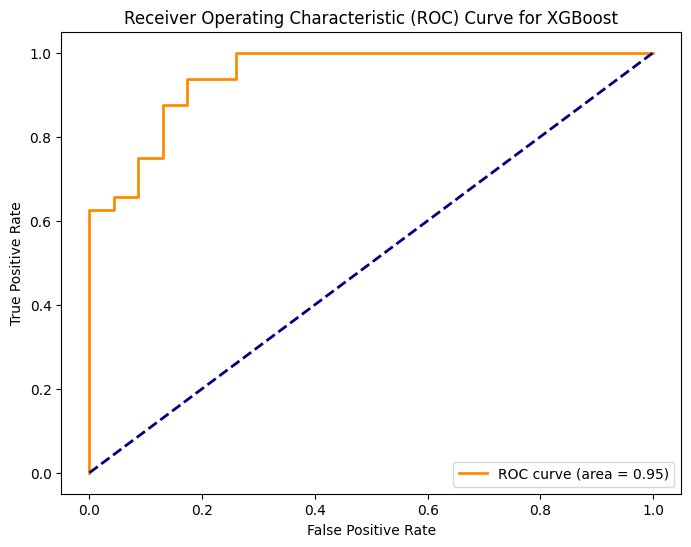

AUC Score for XGBoost: 0.9470108695652173


In [ ]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# ROC Curve for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, best_xgb.predict(X_test))
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label='ROC curve (area = {:.2f})'.format(roc_auc_xgb))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for XGBoost')
plt.legend(loc="lower right")
plt.show()

# Calculate the predicted probabilities for XGBoost
predicted_probabilities_xgb = best_xgb.predict(X_test)

# Calculate AUC score for XGBoost
auc_score_xgb = roc_auc_score(y_test, predicted_probabilities_xgb)

# Print AUC score for XGBoost
print("AUC Score for XGBoost:", auc_score_xgb)
